In [75]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import xarray as xr

from tools.general_functions import PRINT_COLORS, replace_punctuation_in_filenames, apply_root_json
from tools import convert_GIS

import downscaling.settings_downscaling as settings
from downscaling.settings_downscaling_cities import coord_Amsterdam, coord_Lima, coord_Raleigh, coord_NewYork

In [76]:
project_dir = Path.cwd()
data_dir_output = project_dir / "data" / "output"
data_dir_processed = project_dir / "data" / "processed"
data_dir_check = project_dir / "data" / "check" / "urban_comparison"
Path(data_dir_check).mkdir(parents=True, exist_ok=True)
varname_EM = settings.varname_EM

profiles = ["first_round", "second_round", "third_round", "fourth_round", "fifth_round"]
scenarios = ["ELV-SSP2-CP", "ELV-SSP2-1150F"]
SSP_base = "SSP2"

In [77]:
# print global emission profiles

# TO DO: plot for different regions
df_profiles = pd.DataFrame()
for profile in profiles:
    for scenario in scenarios:
        print(f"Checking {profile}...")


        em_path = data_dir_output /f"Emissions_region_combined_{scenario}_{profile}_harmonised.csv"
        #print(f"Reading {em_path}...")
        df_emissions = pd.read_csv(em_path, sep=";")
        df_emissions.drop(columns=["total_iam", "rural", "total_urban_rural", "ratio_iam_grid", "ratio_urban_rural"], inplace=True)
        df_emissions["profile"] = profile
        df_emissions["scenario"] = scenario

        pop_path = data_dir_output /f"Population_region_combined_{scenario}_{profile}_harmonised.csv"
        #print(f"Reading {pop_path}...")
        df_population = pd.read_csv(pop_path, sep=";")
        df_population["profile"] = profile
        df_population["scenario"] = scenario

        df_profiles = pd.concat([df_profiles, df_emissions], ignore_index=True)

print(f"\n{df_profiles.dtypes}")
print(f"\n{df_profiles.sample()}")

Checking first_round...
Checking first_round...
Checking second_round...
Checking second_round...
Checking third_round...
Checking third_round...
Checking fourth_round...
Checking fourth_round...
Checking fifth_round...
Checking fifth_round...

year               int64
region_number      int64
total_grid       float64
urban            float64
profile           object
scenario          object
dtype: object

      year  region_number    total_grid  urban       profile     scenario
2260  2070             20  2.997345e+09    NaN  fourth_round  ELV-SSP2-CP


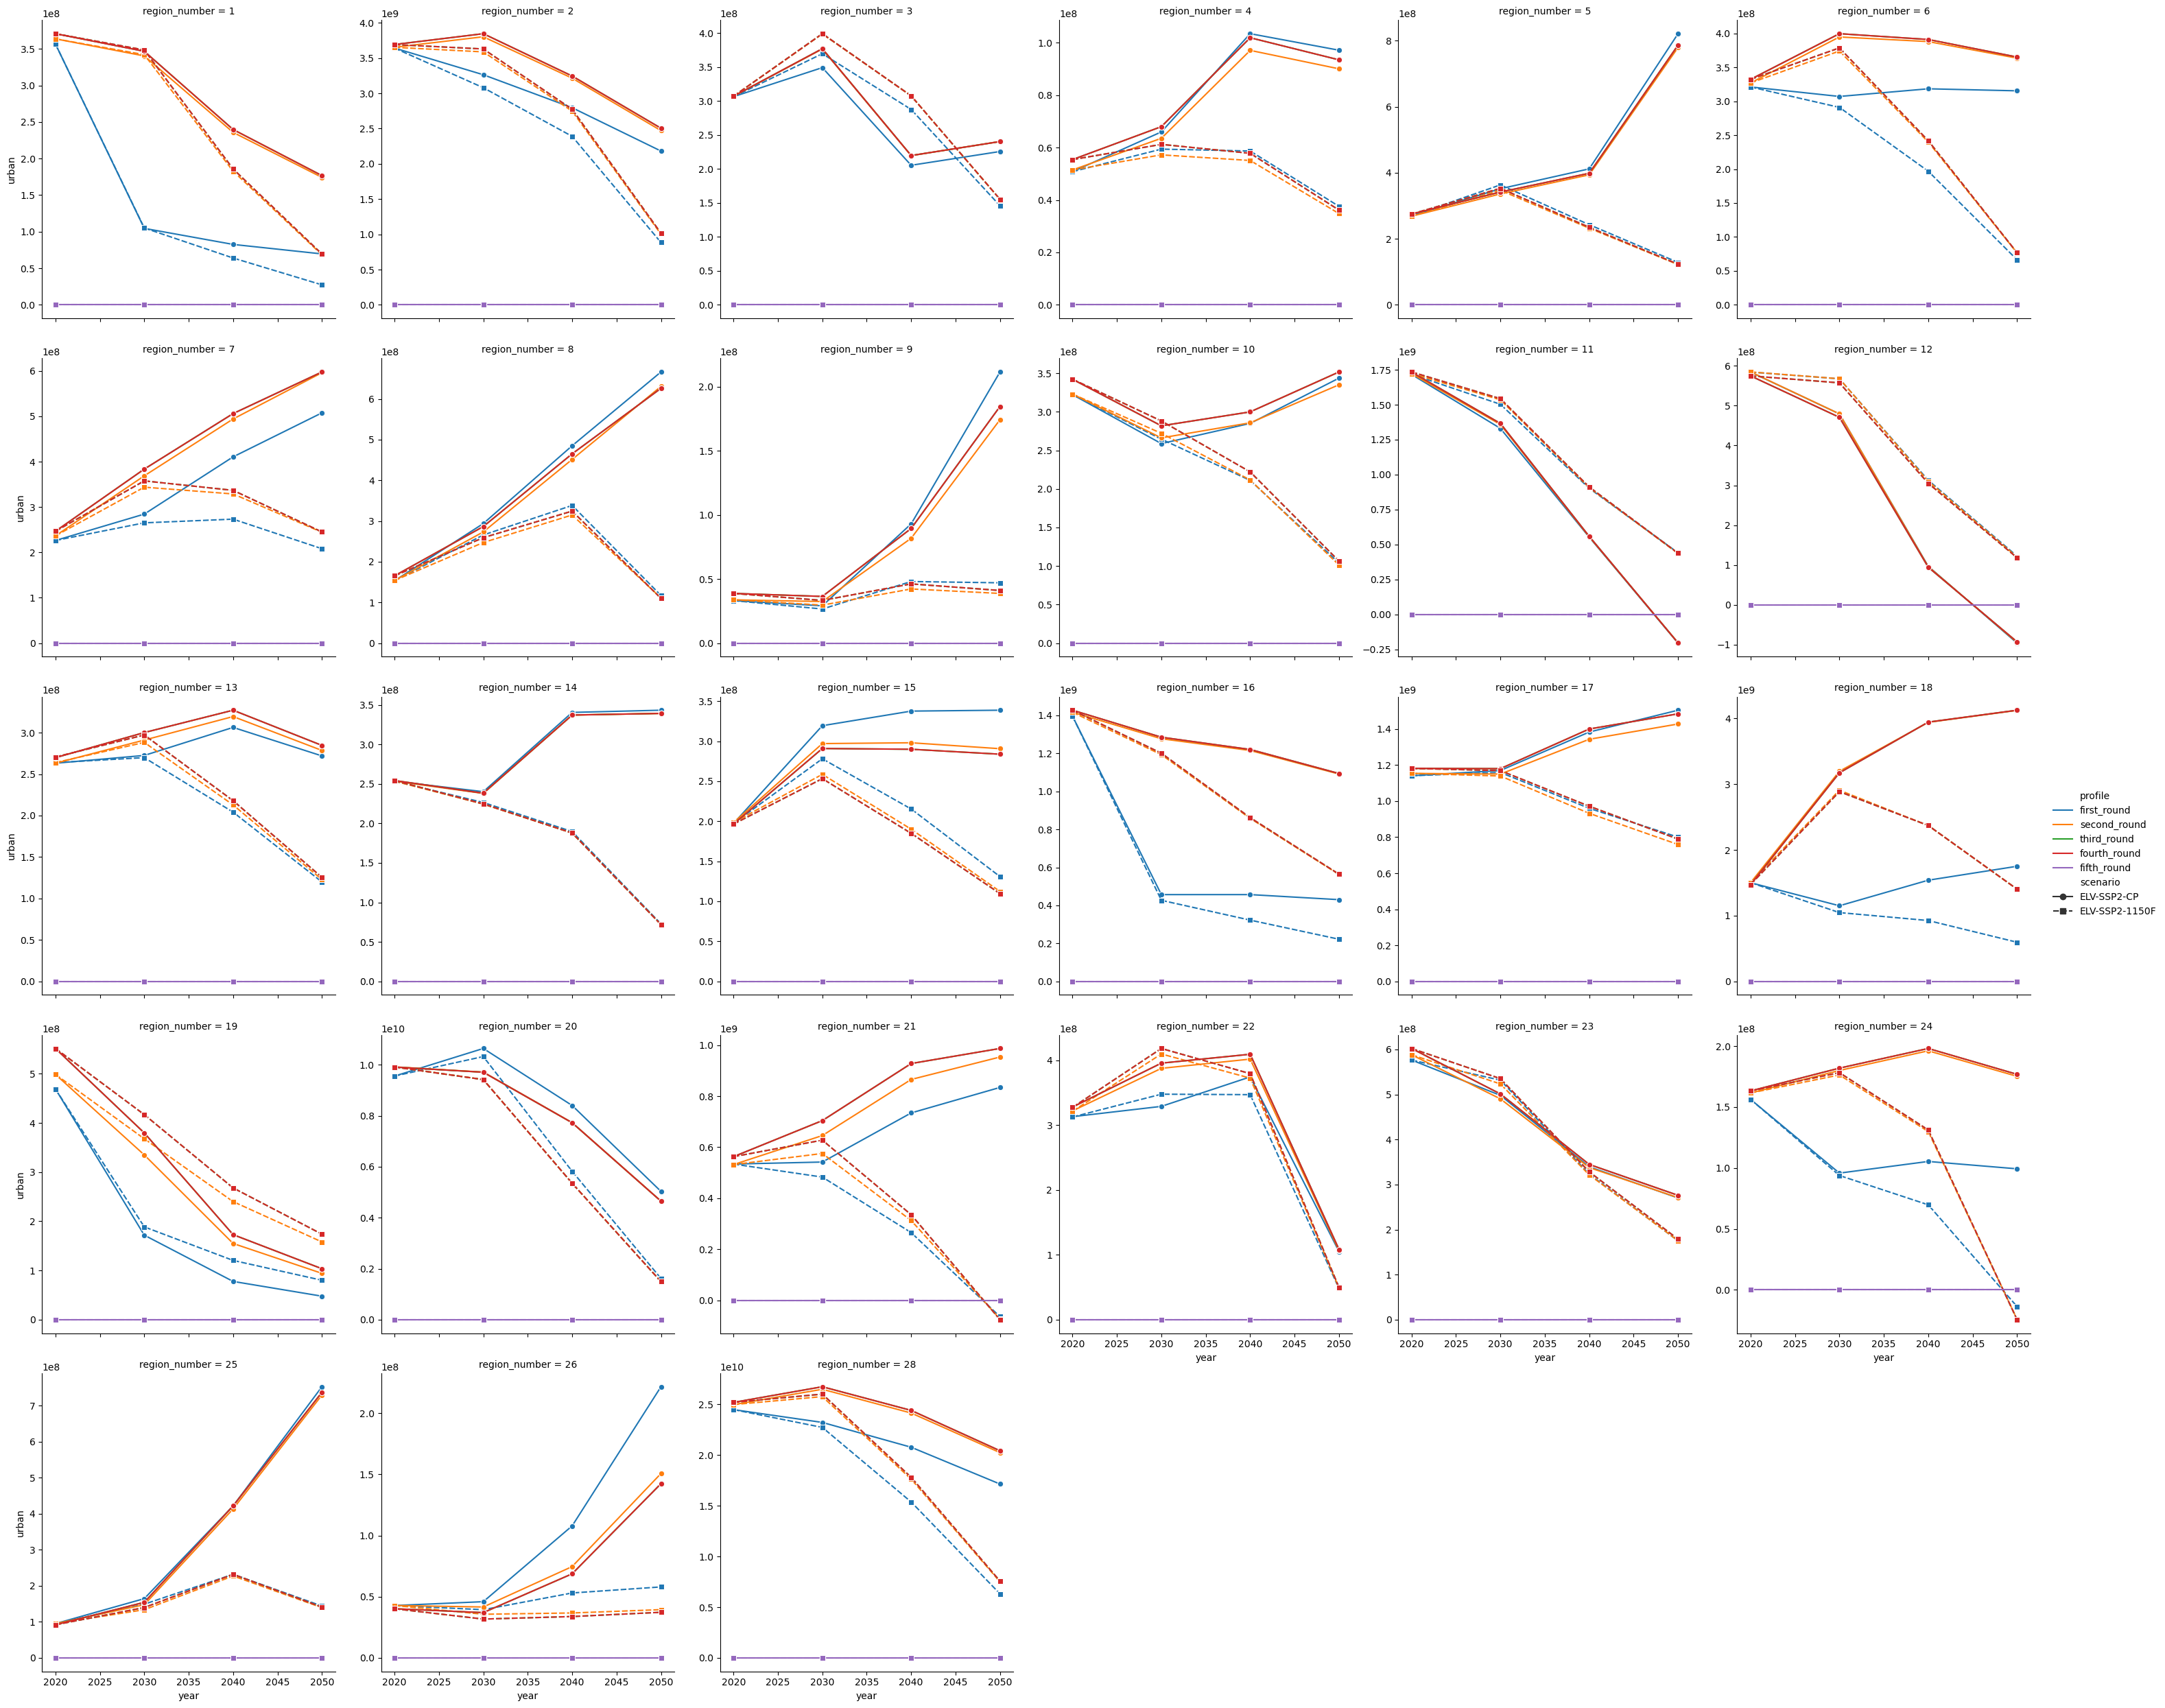

In [78]:
df_profiles_plot = df_profiles[df_profiles["region_number"] != 0]
sns.relplot(data=df_profiles_plot, x="year", y="urban", col="region_number", col_wrap=6, hue="profile", style="scenario",  markers=["o", "s"], kind="line", facet_kws={"sharey": False})

In [79]:
settings_file = project_dir / "downscaling" / "settings_data_locations.json"
with open(settings_file, "r") as f:
    data_files = json.load(f)
data_files = apply_root_json(data_files, data_files["data_root"])
dir_GADM_geopackage = Path(data_files["GADM"]["dir_GADM_geopackage"])
dir_US_Census_Tiger = Path(data_files["US_Census"]["dir_US_Census_TIGER"])
gadm_gpkg_path = dir_GADM_geopackage / "gadm_410-levels.gpkg"

In [80]:
# check a few city city polygons use
output_dir = Path("K:/PythonWork/downscaling/Kaya_downscaling/data/check/polygons")
output_dir.mkdir(parents=True, exist_ok=True)

cities_config = [{"name": "Amsterdam", "within_US": False, "iso3": "NLD", "coords": coord_Amsterdam,
                  "sub_cities": ["Amsterdam", "Rotterdam", "'s-Gravenhage", "Utrecht"]},
                  {"name": "Lima",     "within_US": False, "iso3": "PER", "coords": coord_Lima},
                  #{"name": "Raleigh",  "within_US": True,  "iso3": None,  "coords": coord_Raleigh},
                  #{"name": "New York", "within_US": True,  "iso3": None,  "coords": coord_NewYork}
                ]

years_plot = [2020, 2030, 2040, 2050]
df_emissions = pd.DataFrame(columns=["profile", "city", "year", "emissions_in_polygon"])
for profile in profiles:
    for scenario in scenarios:
        print(gadm_gpkg_path)
        print(output_dir)
        em_harmonised_file = project_dir / "data" / "processed" / f"{profile}/IMAGE_{scenario}" / f"{replace_punctuation_in_filenames(varname_EM)}_harmonised_{SSP_base}.nc"
        xr_emissions_proj = xr.open_dataset(em_harmonised_file)
        for y in years_plot:
            for city in cities_config:
                nm = city["name"]
                print(f"{PRINT_COLORS["yellow"]}City/town: {nm} at coordinates {city['coords']} for year {y}{PRINT_COLORS["end"]}")
                print(f"{PRINT_COLORS["yellow"]}Getting polygon for {nm} in country {city['iso3']}{PRINT_COLORS["end"]}")
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    poly = convert_GIS.get_city_polygon(GADM_gpkg_path=Path(gadm_gpkg_path), iso3=city["iso3"], city_name=city["name"], output_dir=output_dir)
                da_city = xr_emissions_proj[varname_EM].sel(time=y).rio.clip_box(minx=city["coords"][0], miny=city["coords"][2], maxx=city["coords"][1], maxy=city["coords"][3])
                stats = convert_GIS.calculate_emissions_in_polygon(da_city, poly, city["name"])
                df_emissions = pd.concat([df_emissions, pd.DataFrame([{
                    "profile": profile,
                    "city": city["name"],
                    "year": y,
                    "sum_cells": stats["sum_weighted"],
                    "sum_full": stats["sum_full"],
                    "avg_sum_per_cell": stats["mean_per_m2"]
                }])], ignore_index=True)
df_emissions.to_csv(data_dir_check / f"emissions_in_city_polygons_{profile}_{scenario}.csv", sep=";", index=False)



F:\data_downscaling\GADM\geopackage\gadm_410-levels.gpkg
K:\PythonWork\downscaling\Kaya_downscaling\data\check\polygons
City/town: Amsterdam at coordinates [3.0, 7.0, 51.0, 54.0] for year 2020
Getting polygon for Amsterdam in country NLD
Found 'Amsterdam' in layer ADM_2 (1 feature(s)).
Saved city polygon to: K:\PythonWork\downscaling\Kaya_downscaling\data\check\polygons\NLD_Amsterdam.gpkg
  Emissions in 'Amsterdam': sum_weighted=1,663,254.0675, mean_per_m2=0.0085, full_pixels=0, partial_pixels=10
City/town: Lima at coordinates [-79.03, -75.03, -14.05, -10.05] for year 2020
Getting polygon for Lima in country PER
Found 'Lima' in layer ADM_2 (1 feature(s)).
Found 'Lima' in layer ADM_3 (1 feature(s)).
Saved city polygon to: K:\PythonWork\downscaling\Kaya_downscaling\data\check\polygons\PER_Lima.gpkg
  Emissions in 'Lima': sum_weighted=9,534,657.9716, mean_per_m2=0.0037, full_pixels=6, partial_pixels=34
City/town: Amsterdam at coordinates [3.0, 7.0, 51.0, 54.0] for year 2030
Getting polygo